# Analisis Hasil Eksperimen Fairness Lambda

Input: `fairness_lambda_experiment_summary.csv`

1. Membaca hasil eksperimen lambda/fairness.
2. Menghitung rata-rata metrik pada semua K untuk setiap nilai lambda.
3. Membuat satu visualisasi untuk melihat nilai lambda terbaik berdasarkan masing-masing metrik.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

INPUT_FILE = Path("fairness_lambda_experiment_summary.csv")
OUTPUT_DIR = Path("analysis_fairness_lambda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(INPUT_FILE, sep=None, engine="python")
df.columns = df.columns.str.replace("\ufeff", "", regex=False)

print(f"Data dimuat: {df.shape[0]} baris x {df.shape[1]} kolom")
display(df.head())

Data dimuat: 5 baris x 51 kolom


,experiment_id,experiment_name,popularity_id,popularity_features,value_id,value_features,scenario,alpha,beta,gamma,...,mean_fairness@20,mean_f1@20,mean_tp@25,mean_fp@25,mean_fn@25,mean_precision@25,mean_recall@25,mean_ndcg@25,mean_fairness@25,mean_f1@25
0,1,L0p1_B5_countSold_totalRating__G3_ratingAverag...,B5_countSold_totalRating,countSold + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,relevance_dominant_no_fairness,0.5,0.25,0.25,...,0.696667,0.758679,21.400000,3.600000,3.800000,0.856000,0.856575,0.898374,0.680000,0.842510
1,2,L0p2_B5_countSold_totalRating__G3_ratingAverag...,B5_countSold_totalRating,countSold + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,relevance_dominant_no_fairness,0.5,0.25,0.25,...,0.756667,0.744254,21.333333,3.666667,3.866667,0.853333,0.852408,0.892828,0.701333,0.839258
2,3,L0p3_B5_countSold_totalRating__G3_ratingAverag...,B5_countSold_totalRating,countSold + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,relevance_dominant_no_fairness,0.5,0.25,0.25,...,0.810000,0.747957,21.200000,3.800000,4.000000,0.848000,0.844538,0.887176,0.736000,0.832905
3,4,L0p4_B5_countSold_totalRating__G3_ratingAverag...,B5_countSold_totalRating,countSold + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,relevance_dominant_no_fairness,0.5,0.25,0.25,...,0.876667,0.736809,21.000000,4.000000,4.200000,0.840000,0.835430,0.874040,0.797333,0.824547
4,5,L0p5_B5_countSold_totalRating__G3_ratingAverag...,B5_countSold_totalRating,countSold + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,relevance_dominant_no_fairness,0.5,0.25,0.25,...,0.896667,0.722441,20.800000,4.200000,4.400000,0.832000,0.819388,0.867466,0.810667,0.813799


## Konfigurasi metrik dan K

In [2]:
METRICS = ["precision", "recall", "ndcg", "fairness", "f1"]
K_VALUES = [5, 10, 15, 20, 25]

metric_cols = {
    metric: [f"mean_{metric}@{k}" for k in K_VALUES]
    for metric in METRICS
}

missing_cols = [
    col
    for cols in metric_cols.values()
    for col in cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(f"Kolom metrik berikut tidak ditemukan: {missing_cols}")

if "lambda" not in df.columns:
    raise ValueError("Kolom 'lambda' tidak ditemukan di file input.")

METRIC_COLORS = {
    "precision": "#185FA5",
    "recall": "#0F6E56",
    "ndcg": "#854F0B",
    "fairness": "#A23B72",
    "f1": "#534AB7",
}

BAR_NORMAL = "#B4B2A9"

print("Semua kolom metrik tersedia.")

Semua kolom metrik tersedia.


## Fungsi bantu

In [3]:
def make_avg_metric_columns(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()

    for metric, cols in metric_cols.items():
        result[f"avg_{metric}_allK"] = result[cols].mean(axis=1)

    return result


def summarize_by_lambda(data: pd.DataFrame) -> pd.DataFrame:
    temp = make_avg_metric_columns(data)

    avg_cols = [f"avg_{metric}_allK" for metric in METRICS]

    summary = (
        temp.groupby("lambda", as_index=False)[avg_cols]
        .mean()
        .sort_values("lambda")
        .reset_index(drop=True)
    )

    return summary


def plot_lambda_grouped_bar(lambda_summary, output_name):
    """
    Plot grouped bar rata-rata metrik semua K untuk setiap lambda.

    Highlight diberikan pada bar tertinggi untuk masing-masing metrik:
    - precision tertinggi
    - recall tertinggi
    - ndcg tertinggi
    - fairness tertinggi
    - f1 tertinggi
    """

    plot_df = lambda_summary.sort_values("lambda").reset_index(drop=True).copy()

    metric_cols = [
        "avg_precision_allK",
        "avg_recall_allK",
        "avg_ndcg_allK",
        "avg_fairness_allK",
        "avg_f1_allK",
    ]

    metrics_plot = [
        "precision",
        "recall",
        "ndcg",
        "fairness",
        "f1",
    ]

    x_labels = plot_df["lambda"].astype(str).tolist()
    x = np.arange(len(x_labels))

    n_metrics = len(metric_cols)
    width = 0.15

    # Cari index pemenang untuk setiap metrik
    winner_idx_by_metric = {}

    for metric, col in zip(metrics_plot, metric_cols):
        winner_idx_by_metric[metric] = int(plot_df[col].idxmax())

    fig, ax = plt.subplots(figsize=(11, 6))

    for i, (metric, col) in enumerate(zip(metrics_plot, metric_cols)):
        values = plot_df[col].to_numpy(dtype=float)
        metric_winner_idx = winner_idx_by_metric[metric]

        colors = []
        edgecolors = []
        linewidths = []

        for j in range(len(plot_df)):
            if j == metric_winner_idx:
                colors.append(METRIC_COLORS[metric])
                edgecolors.append("black")
                linewidths.append(1.8)
            else:
                colors.append(BAR_NORMAL)
                edgecolors.append("none")
                linewidths.append(0)

        bars = ax.bar(
            x + (i - n_metrics / 2 + 0.5) * width,
            values,
            width,
            color=colors,
            edgecolor=edgecolors,
            linewidth=linewidths,
            alpha=0.9,
            label=metric.capitalize(),
            zorder=3,
        )

        # Bintang pada bar tertinggi metrik tersebut
        winner_bar = bars[metric_winner_idx]
        bar_x = winner_bar.get_x() + winner_bar.get_width() / 2
        bar_y = winner_bar.get_height()

        ax.annotate(
            "★",
            xy=(bar_x, bar_y),
            xytext=(bar_x, bar_y + 0.012),
            ha="center",
            fontsize=11,
            color=METRIC_COLORS[metric],
            fontweight="bold",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)

    ax.set_title(
        "Rata-rata Metrik Semua K pada Setiap Nilai Lambda",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("Nilai Lambda")
    ax.set_ylabel("Rata-rata metrik semua K")

    all_values = plot_df[metric_cols].to_numpy(dtype=float)
    min_val = np.nanmin(all_values)
    max_val = np.nanmax(all_values)

    ax.set_ylim(min_val - 0.02, max_val + 0.08)

    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    # Anotasi ringkas pemenang per metrik
    winner_text = []
    for metric in metrics_plot:
        idx = winner_idx_by_metric[metric]
        lambda_value = plot_df.loc[idx, "lambda"]
        winner_text.append(f"{metric.upper()}: λ={lambda_value}")

    ax.text(
        1.02,
        0.35,
        "Pemenang per metrik:\n" + "\n".join(winner_text),
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    handles = [
        mpatches.Patch(color=METRIC_COLORS[m], label=m.capitalize())
        for m in metrics_plot
    ]

    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
    )

    plt.tight_layout()

    output_path = OUTPUT_DIR / output_name
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Plot disimpan ke:", output_path)

In [8]:
def make_avg_metric_columns(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()

    for metric, cols in metric_cols.items():
        result[f"avg_{metric}_allK"] = result[cols].mean(axis=1)

    return result


def summarize_by_lambda(data: pd.DataFrame) -> pd.DataFrame:
    temp = make_avg_metric_columns(data)

    avg_cols = [f"avg_{metric}_allK" for metric in METRICS]

    summary = (
        temp.groupby("lambda", as_index=False)[avg_cols]
        .mean()
        .sort_values("lambda")
        .reset_index(drop=True)
    )

    return summary


def plot_lambda_grouped_bar(lambda_summary, output_name):
    """
    Highlight hanya diberikan pada bar fairness tertinggi,
    karena tahap ini bertujuan memilih nilai lambda/fairness boost.
    """

    plot_df = lambda_summary.sort_values("lambda").reset_index(drop=True).copy()

    metric_cols = [
        "avg_precision_allK",
        "avg_recall_allK",
        "avg_ndcg_allK",
        "avg_fairness_allK",
        "avg_f1_allK",
    ]

    metrics_plot = [
        "precision",
        "recall",
        "ndcg",
        "fairness",
        "f1",
    ]

    x_labels = plot_df["lambda"].astype(str).tolist()
    x = np.arange(len(x_labels))

    n_metrics = len(metric_cols)
    width = 0.15

    fairness_col = "avg_fairness_allK"
    fairness_winner_idx = int(plot_df[fairness_col].idxmax())

    fig, ax = plt.subplots(figsize=(11, 6))

    for i, (metric, col) in enumerate(zip(metrics_plot, metric_cols)):
        values = plot_df[col].to_numpy(dtype=float)

        colors = []
        edgecolors = []
        linewidths = []

        for j in range(len(plot_df)):
            if metric == "fairness" and j == fairness_winner_idx:
                colors.append(METRIC_COLORS[metric])
                edgecolors.append("black")
                linewidths.append(1.8)
            else:
                colors.append(BAR_NORMAL)
                edgecolors.append("none")
                linewidths.append(0)

        bars = ax.bar(
            x + (i - n_metrics / 2 + 0.5) * width,
            values,
            width,
            color=colors,
            edgecolor=edgecolors,
            linewidth=linewidths,
            alpha=0.9,
            label=metric.capitalize(),
            zorder=3,
        )

        if metric == "fairness":
            winner_bar = bars[fairness_winner_idx]
            bar_x = winner_bar.get_x() + winner_bar.get_width() / 2
            bar_y = winner_bar.get_height()

            ax.annotate(
                "★",
                xy=(bar_x, bar_y),
                xytext=(bar_x, bar_y + 0.012),
                ha="center",
                fontsize=11,
                color=METRIC_COLORS["fairness"],
                fontweight="bold",
            )

    best_lambda = plot_df.loc[fairness_winner_idx, "lambda"]

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)

    ax.set_title(
        "Rata-rata Metrik Semua K pada Setiap Nilai Lambda",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("Nilai Lambda")
    ax.set_ylabel("Rata-rata metrik semua K")

    all_values = plot_df[metric_cols].to_numpy(dtype=float)
    min_val = np.nanmin(all_values)
    max_val = np.nanmax(all_values)
    ax.set_ylim(min_val - 0.02, max_val + 0.08)

    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    ax.annotate(
        f"Fairness tertinggi\nλ = {best_lambda}",
        xy=(fairness_winner_idx, plot_df.loc[fairness_winner_idx, fairness_col]),
        xytext=(fairness_winner_idx - 0.6, plot_df.loc[fairness_winner_idx, fairness_col] + 0.035),
        arrowprops=dict(arrowstyle="->", color=METRIC_COLORS["fairness"], lw=1.2),
        fontsize=9,
        color=METRIC_COLORS["fairness"],
        fontweight="bold",
    )

    handles = [
        mpatches.Patch(color=METRIC_COLORS[m], label=m.capitalize())
        for m in metrics_plot
    ]

    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
    )

    plt.tight_layout()

    output_path = OUTPUT_DIR / output_name
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Plot disimpan ke:", output_path)

## Lambda terbaik per metrik

In [4]:
lambda_summary = summarize_by_lambda(df)

lambda_summary.to_csv(
    OUTPUT_DIR / "01_lambda_summary_avg_metrics_allK.csv",
    index=False,
)

best_lambda_rows = []

for metric in METRICS:
    col = f"avg_{metric}_allK"
    best_idx = lambda_summary[col].idxmax()

    best_lambda_rows.append({
        "metric": metric,
        "best_lambda": lambda_summary.loc[best_idx, "lambda"],
        "best_value": lambda_summary.loc[best_idx, col],
    })

best_lambda_by_metric = pd.DataFrame(best_lambda_rows)

best_lambda_by_metric.to_csv(
    OUTPUT_DIR / "02_best_lambda_by_each_metric.csv",
    index=False,
)

display(best_lambda_by_metric)

,metric,best_lambda,best_value
0,precision,0.1,0.866978
1,recall,0.1,0.527528
2,ndcg,0.1,0.864623
3,fairness,0.5,0.932578
4,f1,0.1,0.610742


## Analisis lambda

,lambda,avg_precision_allK,avg_recall_allK,avg_ndcg_allK,avg_fairness_allK,avg_f1_allK
0,0.1,0.866978,0.527528,0.864623,0.748667,0.610742
1,0.2,0.858444,0.519891,0.856552,0.838711,0.602974
2,0.3,0.851822,0.513364,0.850442,0.879422,0.596672
3,0.4,0.839778,0.502422,0.840712,0.920133,0.585520
4,0.5,0.834622,0.493187,0.838922,0.932578,0.578012


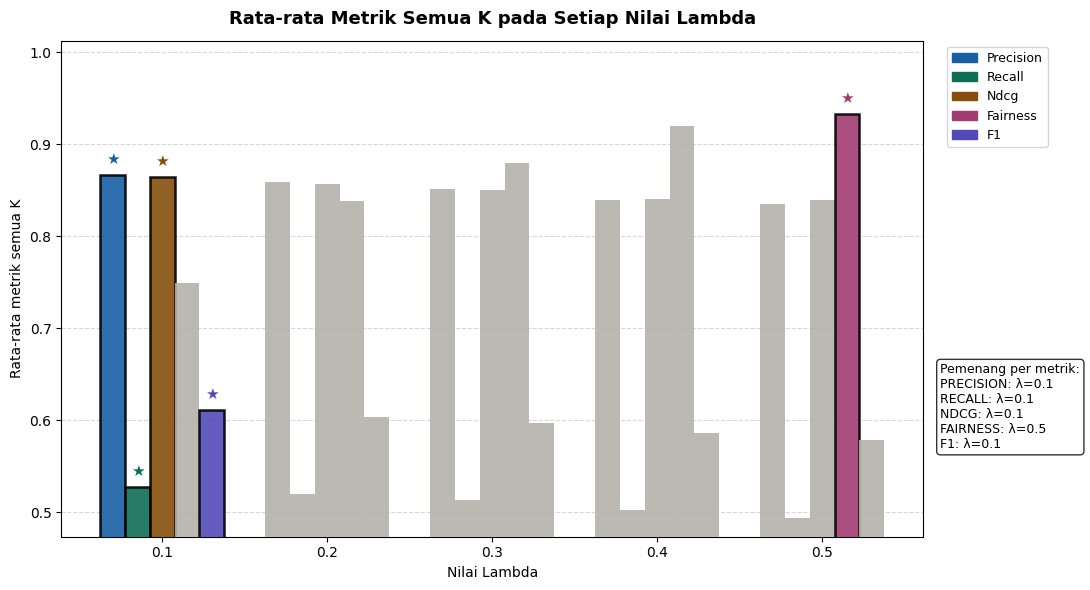

Plot disimpan ke: analysis_fairness_lambda_outputs\01_lambda_summary_avg_metrics_allK.png


In [5]:
display(lambda_summary)

plot_lambda_grouped_bar(
    lambda_summary,
    output_name="01_lambda_summary_avg_metrics_allK.png",
)